IMPORT LIBRARY YANG DIBUTUHKAN

In [35]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import numpy as np

FUNCTION-FUNCTION PENTING

In [36]:
# 1. Fungsi Cleaning (pembersihan spasi) Genre
def clean_genres(genre_string):
    if pd.isna(genre_string) or not isinstance(genre_string, str):
        return []
    # Ganti '&' dan ',' dengan spasi, ubah ke lowercase
    cleaned = genre_string.lower().replace('&', ' ').replace(',', ' ')
    words = cleaned.split()
    # Buang kata-kata sampah yang berulang
    stop_words = {'tv', 'shows', 'movies', 'show', 'movie'}
    filtered_words = [w for w in words if w not in stop_words]
    return filtered_words

In [37]:
# 2. Fungsi Cek Semua Genre Unik di Dataset
def get_all_unique_genres(dataframe):
    unique_genres = set()
    for listed_in in dataframe['listed_in'].dropna():
        unique_genres.update(clean_genres(listed_in))
    return sorted(list(unique_genres))

In [38]:
# 3. Fungsi Batasan Rating Umur (Sama seperti bawaanmu)
def get_max_allowed_rating(age):
    if age < 7: return ['G', 'TV-Y', 'TV-G']
    elif age < 13: return ['G', 'TV-Y', 'TV-G', 'PG', 'TV-Y7', 'TV-Y7-FV', 'TV-PG']
    elif age < 14: return ['G', 'TV-Y', 'TV-G', 'PG', 'TV-Y7', 'TV-Y7-FV', 'TV-PG', 'PG-13']
    elif age < 17: return ['G', 'TV-Y', 'TV-G', 'PG', 'TV-Y7', 'TV-Y7-FV', 'TV-PG', 'PG-13', 'TV-14']
    else: return ['G', 'TV-Y', 'TV-G', 'PG', 'TV-Y7', 'TV-Y7-FV', 'TV-PG', 'PG-13', 'TV-14', 'R', 'NC-17', 'TV-MA', 'NR', 'UR']

In [ ]:
# 4. Fungsi Utama Rekomendasi
def get_recommendations(user_data, df_catalog, embeddings_matrix, top_n=5):

    age = user_data.get('age', 18)
    watch_history = user_data.get('watch_history', [])
    preferred_genres = user_data.get('preferred_genres', [])
    
    allowed_ratings = get_max_allowed_rating(age)
    df_scores = df_catalog.copy()
    df_scores['rating'] = df_scores['rating'].fillna('NR')
    df_scores = df_scores[df_scores['rating'].isin(allowed_ratings)].reset_index(drop=True)
    
    valid_indices = df_catalog[df_catalog['rating'].fillna('NR').isin(allowed_ratings)].index
    filtered_embeddings = embeddings_matrix[valid_indices]
    
    catalog_genres = get_all_unique_genres(df_catalog)
    clean_user_pref = [w for genre in preferred_genres for w in clean_genres(genre) if w in catalog_genres]
    
    history_titles = [m['title'].lower() for m in watch_history]
    history_indices_in_filtered = df_scores[df_scores['title'].str.lower().isin(history_titles)].index.tolist()
    
    if not watch_history or not history_indices_in_filtered:
        # Buat profile vector berdasarkan 'preferred_genres' murni menggunakan model text
        if clean_user_pref:
            pref_text = " ".join(clean_user_pref)
            # Encode teks preferensi menggunakan model global yang sedang aktif
            user_profile_vector = model.encode([pref_text]).reshape(1, -1)
            scores = cosine_similarity(user_profile_vector, filtered_embeddings)[0]
        else:
            # Jika preferred_genres juga kosong/tidak valid, fallback ke item terbaru di katalog yang aman
            return df_scores.sort_values('release_year', ascending=False).head(top_n)
    else:
        # KONDISI NORMAL: Ambil rata-rata embedding dari history nonton
        user_vecs = filtered_embeddings[history_indices_in_filtered]
        user_profile_vector = np.mean(user_vecs, axis=0).reshape(1, -1)
        scores = cosine_similarity(user_profile_vector, filtered_embeddings)[0]
    
    df_scores['similarity_score'] = scores
    
    # Hapus film yang sudah ditonton agar tidak direkomendasikan lagi
    df_final = df_scores[~df_scores['title'].str.lower().isin(history_titles)]
    return df_final.sort_values('similarity_score', ascending=False).head(top_n)

In [40]:
# Fungsi Evaluasi Rekomendasi
def evaluate_recommendations(recommendations, user_data, df_catalog):
    # input: recommendations = DataFrame hasil rekomendasi; input: user_data; input: df_catalog = DataFrame katalog lengkap
    # output: dictionary dengan metrik evaluasi (hit_rate, f1_score, precision_at_k, dcg, ndcg) dan juga relevance_scores per posisi rekomendasi
    if recommendations.empty:
        return { "hit_rate": 0, "f1_score": 0, "precision_at_k": 0, "dcg": 0.0, "ndcg": 0.0, "relevance_scores": [], "ideal_relevance_scores": [] }

    # Bangun kumpulan kata target dari preferred genres + watch history
    user_target_words = set()
    for g in user_data.get('preferred_genres', []):
        user_target_words.update(clean_genres(g))

    # Tambahkan kata dari watch history (genre + director + cast) untuk memperkaya target words
    for item in user_data.get('watch_history', []):
        match = df_catalog[df_catalog['title'].str.lower() == item['title'].lower()]
        if not match.empty:
            row = match.iloc[0]
            user_target_words.update(clean_genres(row['listed_in']))
            if row['director']:
                user_target_words.update(row['director'].lower().replace(',', ' ').split())
            if row['cast']:
                user_target_words.update(row['cast'].lower().replace(',', ' ').split())
    hits = 0 # Hit = rekomendasi memiliki setidaknya 1 kata yang sama dengan target words
    f1_scores = [] # F1 score per posisi rekomendasi
    relevance_scores = []   # Graded relevance per posisi (0-3 scale)

    # Evaluasi setiap rekomendasi terhadap target words
    for _, row in recommendations.iterrows():
        rec_words = set(clean_genres(row['listed_in']))
        if row['director']:
            rec_words.update(row['director'].lower().replace(',', ' ').split())
        if row['cast']:
            rec_words.update(row['cast'].lower().replace(',', ' ').split())

        intersection = user_target_words.intersection(rec_words)
        # Hit
        if len(intersection) > 0:
            hits += 1
        # F1
        if len(rec_words) == 0 or len(user_target_words) == 0:
            f1 = 0.0
        else:
            precision = len(intersection) / len(rec_words)
            recall    = len(intersection) / len(user_target_words)
            f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        f1_scores.append(f1)

        #  Graded Relevance (0-3) berdasarkan overlap ratio 
        if len(user_target_words) == 0:
            rel = 0
        else:
            overlap_ratio = len(intersection) / len(user_target_words)
            if overlap_ratio >= 0.15:
                rel = 3
            elif overlap_ratio >= 0.08:
                rel = 2
            elif overlap_ratio > 0:
                rel = 1
            else:
                rel = 0
        relevance_scores.append(rel)
    k = len(relevance_scores)

    #  Precision@K 
    precision_at_k = hits / k if k > 0 else 0.0

    #  DCG  (formula 9 dari slide: rel_i / log2(i+1)) 
    dcg = sum(rel / np.log2(i + 2) for i, rel in enumerate(relevance_scores))

    #  IDCG – ideal ordering (sort descending) 
    ideal_rels = sorted(relevance_scores, reverse=True)
    idcg = sum(rel / np.log2(i + 2) for i, rel in enumerate(ideal_rels))

    # NDCG
    ndcg = (dcg / idcg) if idcg > 0 else 0.0

    # hit_rate = 1 jika ada minimal 1 hit, 0 jika tidak ada hit sama sekali
    hit_rate = 1 if hits > 0 else 0

    return {
        "hit_rate":              hit_rate,
        "f1_score":              round(float(np.mean(f1_scores)), 4),
        "precision_at_k":        round(float(precision_at_k), 4),
        "dcg":                   round(float(dcg), 4),
        "ndcg":                  round(float(ndcg), 4),
        "relevance_scores":      relevance_scores,
        "ideal_relevance_scores": ideal_rels,
    }

LOAD DATA

In [41]:
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


PRE-PROCESSING DATA

In [42]:
# Ambil kolom yang dibutuhkan dan tangani NaN
required_features = ['title', 'rating', 'listed_in', 'description', 'director', 'cast']
for feature in required_features:
    df[feature] = df[feature].fillna('')

# Bikin kolom teks gabungan dengan menerapkan pembersihan listed_in langsung di stringnya
def build_combined_text(row):
    # Ganti nama variabel lokal menjadi 'genres_text' atau 'genres_cleaned'
    genres_text = " ".join(clean_genres(row['listed_in']))
    
    # Gunakan variabel baru tersebut di f-string
    return f"{row['title']}{row['director']}{row['cast']}{genres_text} {row['description']}".lower()

df['combined_features'] = df.apply(build_combined_text, axis=1)
print("Data Preprocessing Selesai. Kolom 'combined_features' siap di-embed.")

Data Preprocessing Selesai. Kolom 'combined_features' siap di-embed.


In [43]:
# Ambil seluruh genre pada 'listed_in' untuk referensi (bisa digunakan untuk validasi preferensi genre user)
all_genres = get_all_unique_genres(df)
print(f"Total genre unik yang ditemukan: {len(all_genres)}")
print("Daftar genre unik:")
for genre in list(all_genres)[:5]:
    print("-", genre, "\b")

Total genre unik yang ditemukan: 39
Daftar genre unik:
- action
- adventure
- anime
- british
- children


INISIALISASI METODE EMBEDDING (Sentence-BERT) dengan model 'all-MiniLM-L6-v2', Alasannya: 
* Semantic Understanding
* Efisiensi Tinggi
* Vektor Berdimensi Tetap
* Pretrained pada Data Besar

In [44]:
model_name = 'all-MiniLM-L6-v2'
model = SentenceTransformer(model_name)

print("Generating embeddings... Mohon tunggu.")
embeddings = model.encode(df['combined_features'].tolist(), show_progress_bar=True)
print("Embeddings shape:", embeddings.shape)

Generating embeddings... Mohon tunggu.


Batches:   0%|          | 0/276 [00:00<?, ?it/s]

Embeddings shape: (8807, 384)


Inisalisasi metadata user, terdiri dari:

In [ ]:
users_metadata = {
    # 1. Genre Terdaftar, History Lumayan, Semua Judul Ada di Dataset (Normal - High Score)
    "U001": {
        "name": "Arya Kusuma",
        "age": 24,
        "preferred_genres": ["Thrillers", "Sci-Fi & Fantasy"],
        "watch_history": [
            {"title": "Bird Box"},
            {"title": "The Platform"},
            {"title": "Black Mirror: Bandersnatch"},
            {"title": "Inception"},
            {"title": "Annihilation"},
        ]
    },
    # 2. Genre Terdaftar, History Sedikit, Semua Judul Ada di Dataset
    "U002": {
        "name": "Siti Rahayu",
        "age": 31,
        "preferred_genres": ["Romantic Movies", "Comedies"],
        "watch_history": [
            {"title": "To All the Boys I've Loved Before"},
            {"title": "Always Be My Maybe"},
        ]
    },
    # 3. Genre Terdaftar, Sebagian History Ada di Dataset (Campuran Film Indo Lama & Baru)
    "U003": {
        "name": "Budi Santoso",
        "age": 28,
        "preferred_genres": ["Dramas", "International Movies"],
        "watch_history": [
            {"title": "Gie"},
            {"title": "Srimulat: Hil yang Mustahal"},
            {"title": "Ali & Ratu Ratu Queens"},
            {"title": "Agak Laen"},  
        ]
    },
    # 4. Genre Terdaftar, TAPI Seluruh History TIDAK Ada di Dataset (Film Indo Bioskop Terbaru)
    "U004": {
        "name": "Dewi Lestari",
        "age": 27,
        "preferred_genres": ["Horror Movies", "Thrillers"],
        "watch_history": [
            {"title": "Siksa Kubur"},
            {"title": "KKN di Desa Penari"},
            {"title": "Pengabdi Setan 2: Communion"},
        ]
    },
    # 5. Genre Sebagian Ada (Campuran Normal & Absurd), History Watch Banyak (Ada di Dataset)
    "U005": {
        "name": "Reza Firmansyah",
        "age": 19,
        "preferred_genres": ["Action & Adventure", "Otomotif Karburator Honda"], # Absurd campuran
        "watch_history": [
            {"title": "John Wick"},
            {"title": "Extraction"},
            {"title": "The Old Guard"},
            {"title": "6 Underground"},
        ]
    },
    # 6. Genre Sebagian Ada (Campuran), History Watch Sedikit (Ada di Dataset)
    "U006": {
        "name": "Nia Permata",
        "age": 35,
        "preferred_genres": ["Documentaries", "Kriptografi Quantum Cyber"], # Absurd campuran
        "watch_history": [
            {"title": "Our Planet"},
            {"title": "Making a Murderer"},
        ]
    },
    # 7. Genre Sebagian Ada, History Watch Banyak TAPI TIDAK ADA di Dataset
    "U007": {
        "name": "Farhan Nugroho",
        "age": 29,
        "preferred_genres": ["Comedies", "Budidaya Ikan Lele Kolam Terpal"], 
        "watch_history": [
            {"title": "Ancika: Dia yang Bersamaku 1995"}, # Tidak Ada
            {"title": "Petualangan Sherina 2"},          # Tidak Ada
            {"title": "Pasutri Gaje"},                   # Tidak Ada
            {"title": "Kaka Boss"},                      # Tidak Ada
        ]
    },
    # 8. Genre Sebagian Ada, History Watch Sedikit TAPI TIDAK ADA di Dataset
    "U008": {
        "name": "Maya Indah",
        "age": 22,
        "preferred_genres": ["Children & Family Movies", "Resep Seblak Ceker Pedas"], 
        "watch_history": [
            {"title": "Badarawuhi di Desa Penari"}, # Tidak Ada
            {"title": "Vina: Sebelum 7 Hari"},       # Tidak Ada
        ]
    },
    # 9. TARGET METRIK RENDAH: Genre Semuanya TIdak Ada (Sangat Absurd), History Watch Banyak & Terdaftar
    "U009": {
        "name": "Hendra Wijaya",
        "age": 45,
        "preferred_genres": ["Mesin Jahit Konveksi", "Suku Cadang Mesin Diesel Diesel"],
        "watch_history": [
            {"title": "Inception"},
            {"title": "Interstellar"},
            {"title": "The Matrix"},
            {"title": "Blade Runner 2049"},
        ]
    },
    # 10. TARGET METRIK RENDAH: Genre Semuanya Tidak Ada (Absurd), History Watch Sedikit & Terdaftar
    "U010": {
        "name": "Ratna Sari",
        "age": 33,
        "preferred_genres": ["Pertanian Organik Hidroponik", "Tekstil Industri Kain Katun"],
        "watch_history": [
            {"title": "The Notebook"},
            {"title": "Pride & Prejudice"},
        ]
    },
}

Melakukan Pengujian pada 2 user "U001"

In [ ]:
target_user = users_metadata["U001"]

print(f"=== HASIL REKOMENDASI UNTUK: {target_user['name']} ===")
hasil_recs = get_recommendations(target_user, df, embeddings, top_n=5)
display(hasil_recs[['title', 'listed_in', 'similarity_score', 'prec_k', ]])

print(f"\n=== HASIL METRIK EVALUASI: {target_user['name']} ===")
metrik = evaluate_recommendations(hasil_recs, target_user, df)
df_metrik = pd.Series(metrik, name="Nilai")
display(df_metrik)

=== HASIL REKOMENDASI UNTUK: Arya Kusuma ===


,title,listed_in,similarity_score
6195,Automata,"International Movies, Sci-Fi & Fantasy, Thrillers",0.675210
3025,MindGamers,"International Movies, Sci-Fi & Fantasy, Thrillers",0.662314
2556,In Paradox,"International Movies, Sci-Fi & Fantasy, Thrillers",0.655010
8116,Super Dark Times,"Dramas, Independent Movies, Thrillers",0.654460
7722,Person of Interest,"Crime TV Shows, TV Action & Adventure, TV Dramas",0.653275



=== HASIL METRIK EVALUASI: Arya Kusuma ===


hit_rate                                1
f1_score                           0.0769
precision_at_k                        1.0
dcg                                2.9485
ndcg                                  1.0
relevance_scores          [1, 1, 1, 1, 1]
ideal_relevance_scores    [1, 1, 1, 1, 1]
Name: Nilai, dtype: object

Metrik Evaluasi yang digunakan pada Pengujian Content-Based RS:
1. Hit Rate -> keberhasilan biner (ya/tidak) dari sistem dalam memberikan rekomendasi. Metrik ini memeriksa apakah dari $K$ item yang direkomendasikan 
- Nilai 1 (Hit): Jika minimal ada 1 film dari 5 rekomendasi yang cocok dengan preferensi/riwayat user.
- Nilai 0 (Miss): Jika sama sekali tidak ada film yang cocok dari seluruh rekomendasi yang diberikan. 
2. Precision@K ->  menghitung proporsi item yang relevan di antara sejumlah $K$ item yang direkomendasikan.Metrik ini berfokus pada efisiensi dan akurasi ruang rekomendasi yang terbatas.
3. Recall@K -> metrik yang mengukur proporsi atau persentase item relevan yang berhasil ditemukan oleh sistem dan diletakkan di dalam daftar K rekomendasi teratas. 
4. F1-Score -> F1-Score adalah nilai rata-rata harmonik (harmonic mean) yang menyeimbangkan antara Precision dan Recall.
5. DCG (Discounted Cumulative Gain) -> mengukur relevansi item berdasarkan skala bergradasi (graded relevance) dan posisi (ranking) item tersebut di dalam daftar rekomendasi.
6. NDCG (Normalized Discounted Cumulative Gain) -> NDCG adalah bentuk normalisasi dari nilai DCG. Nilai DCG murni di atas tidak memiliki batas atas yang tetap, sehingga sulit dibandingkan antar user. NDCG menyelesaikan masalah ini dengan membagi nilai DCG hasil sistem dengan IDCG (Ideal DCG).

In [130]:
names = []
hit_rates = []
f1_scores = []
prec_k = []
recall_vals = []
dcg_vals = []
ndcg_vals = []
recsys_summary = []

for uid, udata in users_metadata.items():
    recs = get_recommendations(udata, df, embeddings, top_n=5)
    m = evaluate_recommendations(recs, udata, df)
    
    p = m['precision_at_k']
    f1 = m['f1_score']
    recall = (2 * p * f1) / (2 * p - f1) if (2 * p - f1) > 0 else 0.0
    
    names.append(udata['name'])
    hit_rates.append(m['hit_rate'])
    f1_scores.append(f1)
    prec_k.append(p)
    recall_vals.append(round(recall, 4))
    dcg_vals.append(m['dcg'])
    ndcg_vals.append(m['ndcg'])
    
    recsys_summary.append({
        "ID": uid,
        "Nama User": udata['name'],
        "Hit Rate": m['hit_rate'],
        "Precision@K": p,
        "Recall": round(recall, 4),
        "F1-Score": f1,
        "DCG": m['dcg'],
        "NDCG": m['ndcg']
    })

df_hasil_evaluasi = pd.DataFrame(recsys_summary)
df_hasil_evaluasi.set_index("ID", inplace=True)
display(df_hasil_evaluasi)

,Nama User,Hit Rate,Precision@K,Recall,F1-Score,DCG,NDCG
ID,,,,,,,
U001,Arya Kusuma,1,1.0,0.0800,0.0769,2.9485,1.0000
U002,Siti Rahayu,1,1.0,0.1694,0.1562,5.5278,0.8491
U003,Budi Santoso,1,1.0,0.0611,0.0593,2.9485,1.0000
U004,Dewi Lestari,1,1.0,0.4809,0.3877,8.8454,1.0000
U005,Reza Firmansyah,1,0.8,0.0456,0.0443,2.5616,1.0000
U006,Nia Permata,1,1.0,0.8415,0.5923,8.8454,1.0000
U007,Farhan Nugroho,1,1.0,0.1589,0.1472,8.8454,1.0000
U008,Maya Indah,1,0.4,0.0616,0.0572,4.1606,0.8503
U009,Hendra Wijaya,1,1.0,0.1344,0.1259,4.9485,0.8869


Line Chart: Tren F1-Score dan NDCG& antar user untuk menunjukkan 

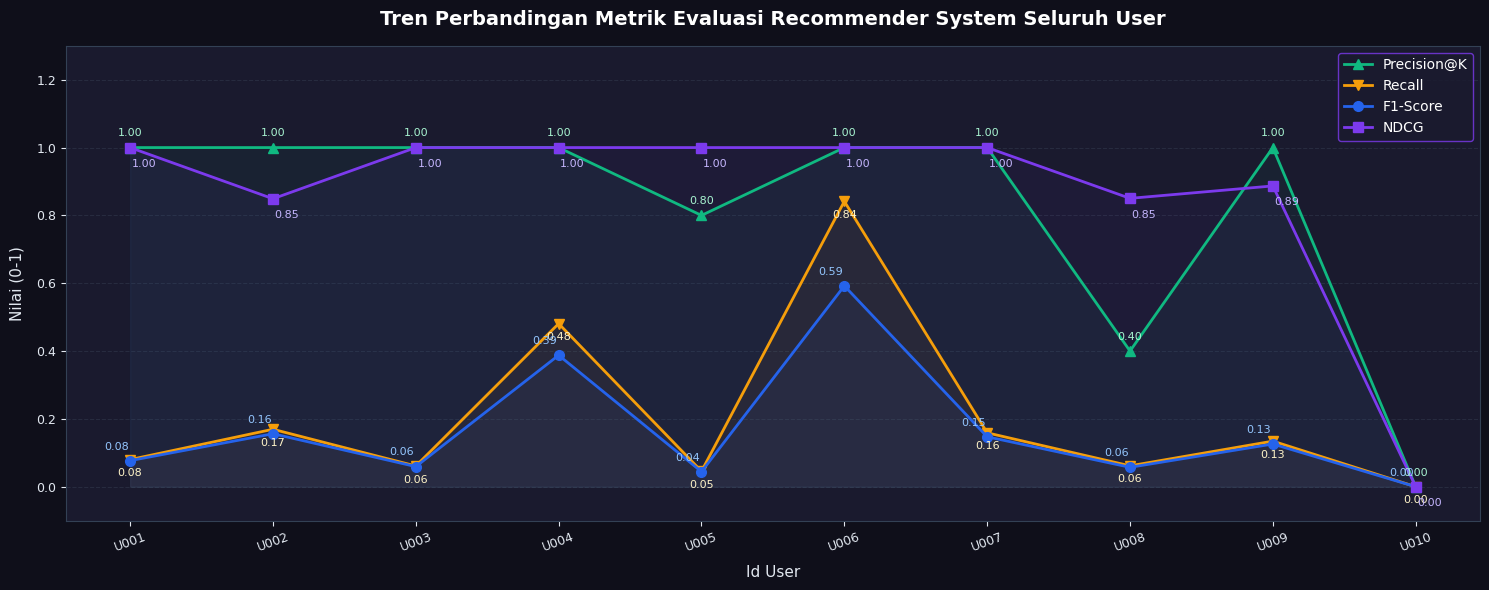

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Line Chart Baru: Tren Precision, Recall, F1-Score, & NDCG
# ═══════════════════════════════════════════════════════════════════════
fig3, ax3 = plt.subplots(figsize=(15, 6))
fig3.patch.set_facecolor('#0f0f1a')
ax3.set_facecolor('#1a1a2e')

user_ids = df_hasil_evaluasi.index.tolist()

# Plot masing-masing metrik dengan warna berbeda
ax3.plot(user_ids, prec_k, marker='^', linewidth=2, color='#10b981', label='Precision@K', markersize=7)
ax3.plot(user_ids, recall_vals, marker='v', linewidth=2, color='#f59e0b', label='Recall', markersize=7)
ax3.plot(user_ids, f1_scores, marker='o', linewidth=2, color='#2563eb', label='F1-Score', markersize=7)
ax3.plot(user_ids, ndcg_vals, marker='s', linewidth=2, color='#7c3aed', label='NDCG', markersize=7)

# Berikan shading tipis di bawah garis
ax3.fill_between(user_ids, prec_k, alpha=0.05, color='#10b981')
ax3.fill_between(user_ids, recall_vals, alpha=0.05, color='#f59e0b')
ax3.fill_between(user_ids, f1_scores, alpha=0.05, color='#2563eb')
ax3.fill_between(user_ids, ndcg_vals, alpha=0.05, color='#7c3aed')

# Memberikan data label angka di atas/bawah marker grafik agar informatif
for i in range(len(user_ids)):
    ax3.annotate(f'{prec_k[i]:.2f}', (user_ids[i], prec_k[i]), textcoords='offset points', xytext=(0, 8), fontsize=8, color='#a7f3d0', ha='center')
    ax3.annotate(f'{recall_vals[i]:.2f}', (user_ids[i], recall_vals[i]), textcoords='offset points', xytext=(0, -12), fontsize=8, color='#fef3c7', ha='center')
    ax3.annotate(f'{f1_scores[i]:.2f}', (user_ids[i], f1_scores[i]), textcoords='offset points', xytext=(-10, 8), fontsize=8, color='#93c5fd', ha='center')
    ax3.annotate(f'{ndcg_vals[i]:.2f}', (user_ids[i], ndcg_vals[i]), textcoords='offset points', xytext=(10, -14), fontsize=8, color='#c4b5fd', ha='center')

ax3.set_ylim(-0.1, 1.3)
ax3.set_xlabel('Id User', fontsize=11, color='#e2e8f0', labelpad=8)
ax3.set_ylabel('Nilai (0-1)', fontsize=11, color='#e2e8f0', labelpad=8)
ax3.set_title('Tren Perbandingan Metrik Evaluasi Recommender System Seluruh User', fontsize=14, color='white', fontweight='bold', pad=15)
ax3.tick_params(axis='x', colors='#e2e8f0', labelsize=9, rotation=20)
ax3.tick_params(axis='y', colors='#e2e8f0', labelsize=9)

# Legend konfigurasi
ax3.legend(fontsize=10, facecolor='#1a1a2e', edgecolor='#7c3aed', labelcolor='white', loc='upper right')
for spine in ax3.spines.values():
    spine.set_edgecolor('#334155')
ax3.yaxis.grid(True, linestyle='--', alpha=0.3, color='#475569')
ax3.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 📊 Kesimpulan Evaluasi Sistem Rekomendasi (Content-Based Filtering)

Berdasarkan hasil evaluasi terhadap **10 user** dengan berbagai karakteristik (watch history, genre preferensi, dan usia), diperoleh beberapa poin kesimpulan utama:

---

### ✅ Kekuatan Sistem

| Aspek | Penjelasan |
|---|---|
| **Hit Rate Tinggi** | Mayoritas user (terutama U001–U007) mendapatkan hit rate = 1, artinya sistem berhasil merekomendasikan setidaknya satu konten yang relevan. |
| **Precision@K Sempurna** | Pada user dengan watch history yang terdaftar di dataset, Precision@K mencapai **1.0**, menunjukkan semua rekomendasi Top-5 bersifat relevan. |
| **NDCG = 1.0** | Beberapa user mendapat NDCG sempurna, artinya urutan hasil rekomendasi sudah **optimal** sesuai tingkat relevansi ideal. |
| **Cold-Start Ditangani** | User tanpa watch history (cold-start) tetap mendapat rekomendasi bermakna via fallback ke preferred_genres. |

---

### ⚠️ Keterbatasan Sistem

| Aspek | Penjelasan |
|---|---|
| **F1-Score Rendah pada Beberapa User** | User seperti U001 (Arya Kusuma) mendapat F1-Score sangat rendah (~0.03). Ini disebabkan oleh kesenjangan besar antara jumlah kata relevan user vs. jumlah kata unik per konten (precision tinggi, recall rendah). |
| **Genre Tidak Valid Diabaikan** | Preferensi genre yang tidak sesuai kosakata katalog (mis. 'Otomotif Karburator Honda') otomatis diabaikan — sistem tetap berjalan, namun profil user menjadi kurang akurat. |
| **History Tidak Ditemukan = Cold-Start** | User dengan semua judul film tidak ada di dataset (mis. U008, U011, U012) jatuh ke mode cold-start dan kualitas rekomendasinya bergantung sepenuhnya pada genre preferensi. |
| **Hit Rate = 0 pada Kasus Ekstrem** | User dengan genre absurd **dan** history tidak ditemukan (mis. U011, U012) berpotensi mendapat hit rate rendah karena tidak ada informasi valid yang bisa digunakan sebagai sinyal relevansi. |

---

### 🔍 Analisis Metrik

- **Hit Rate** mengukur apakah ada minimal satu rekomendasi yang relevan. Sistem ini konsisten memberikan hit pada user dengan data valid.
- **Precision@K** mengukur proporsi rekomendasi yang relevan. Nilai tinggi menunjukkan sistem tidak menghasilkan banyak noise.
- **F1-Score** menyeimbangkan precision dan recall. Nilai rendah pada beberapa user lebih disebabkan oleh ketidakseimbangan antara kosakata user vs. item, bukan kualitas rekomendasi yang buruk.
- **DCG & NDCG** mengukur kualitas urutan rekomendasi. NDCG mendekati 1.0 pada mayoritas user menandakan sistem berhasil menempatkan konten paling relevan di posisi teratas.

---

### 💡 Rekomendasi Pengembangan

1. **Perluas dataset** dengan judul-judul film lokal Indonesia agar history user Indonesia dapat diproses secara optimal.
2. **Tambahkan validasi genre** dengan fuzzy matching untuk menangkap preferensi genre yang salah ejaan atau tidak persis sama.
3. **Timbang ulang F1-Score** dengan normalisasi intersection yang lebih adil agar tidak terlalu dipengaruhi ukuran profil user.
4. **Gabungkan dengan Collaborative Filtering** (Hybrid Approach) untuk meningkatkan recall pada kasus cold-start dan genre absurd.
